# **DEEP LEARNING INTRODUCTION**
___

**MATERIALS**
1. [Penerapan Multilayer Perceptron (MLP): Penjelasan dan Studi Kasus](#1)
    - [Konsep MLP](#11)
    - [Studi Kasus](#12)
2. [Penerapan Convolutional Neural Netowrk (CNN): Penjelasan dan Studi Kasus](#2)
    - [Konsep CNN](#21)
    - [Studi Kasus](#22)
3. [Penerapan Transfer Learning: Penjelasan dan Studi Kasus](#3)
    - [Konsep Transfer Learning](#31)
    - [Studi Kasus](#32)

---

**SOURCES**
1. Tensorflow Keras:
    - Ver. 2.12.0
    - Documentations: https://www.tensorflow.org/versions/r2.12/api_docs/python/tf
    - Github: https://github.com/tensorflow/tensorflow
2. Datasets
    - CIFAR10: https://www.cs.toronto.edu/~kriz/cifar.html
    - MNIST: https://www.tensorflow.org/datasets/catalog/mnist
    - Tiny ImageNet: https://git.ece.iastate.edu/teaching/cpre487_587/tiny-imagenet-tfds (as pretrained weight)

---

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2" # Ignore TensorFlow INFO and WARNING messages

import tensorflow as tf
from tensorflow.python.client import device_lib

SEED = 42
tf.keras.utils.set_random_seed(SEED) # Set tf global random seed
tf.config.experimental.enable_op_determinism()

# Check for GPU availability
gpus = tf.config.list_physical_devices("GPU")
print(f"GPU Available: {bool(gpus)}")

if gpus:
    # !nvidia-smi
    tf.config.set_visible_devices(gpus, 'GPU')
    usage_devices = [gpu.name for gpu in tf.config.list_logical_devices('GPU')]

    devices = device_lib.list_local_devices()
    print("\nUsage Devices:")
    for dev in devices:
        if dev.name in usage_devices and dev.device_type == "GPU":
            print("Device:", dev.name)
            print("Description:", dev.physical_device_desc)


GPU Available: True

Usage Devices:
Device: /device:GPU:0
Description: device: 0, name: NVIDIA A100-SXM4-40GB MIG 2g.10gb, pci bus id: 0000:01:00.0, compute capability: 8.0


In [3]:
# Libraries and variables
import numpy as np
from matplotlib import pyplot as plt

import tensorflow_datasets as tfds
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

# Create directories to store datasets and checkpoints
os.makedirs("/app/datasets", exist_ok=True)
os.makedirs("/app/checkpoints", exist_ok=True)

DATA_PATH = "/app/datasets"
CKPT_PATH = "/app/checkpoints"

In [4]:
# Generate plots for training results
def generate_plot(result):
    plt.figure(figsize=(12, 4))
    for idx, metric in enumerate(["Loss", "Accuracy"]):
        plt.subplot(1, 2, idx+1)
        plt.plot(result.history[metric.lower()], label=f'Training {metric}')
        plt.plot(result.history[f'val_{metric.lower()}'], label=f'Validation {metric}')
        plt.xlabel('Epoch')
        plt.ylabel(f'{metric}')
        plt.legend()
        plt.title(f'{metric} Over Time')
    plt.show()

<a id="1"></a>
## **1. Penerapan Multilayer Perceptron (MLP): Penjelasan dan Studi Kasus**
---

<a id=11></a>
### **1.1 Konsep MLP**

Multilayer Perceptron (MLP) adalah salah satu fundamental dari Deep Learning.
Sebagaimana namanya, MLP terdiri dari banyak layer neuron atau perceptron. MLP
biasanya memiliki tiga jenis layer: input layer, hidden layer, dan output layer.

__Struktur MLP__

1. __Input Layer:__ Layer ini terdiri dari neuron yang merepresentasikan setiap fitur dalam data. Misalnya, jika kamu memiliki data gambar 28x28 pixel, maka input layer akan memiliki 784 neuron.

2. __Hidden Layer:__ Hidden layer berisi sejumlah neuron yang memproses informasi dari input layer. MLP bisa memiliki lebih dari satu hidden layer, inilah yang membuatnya menjadi "Deep" Neural Network.

3. __Output Layer:__ Layer ini berisi neuron yang merepresentasikan kelas atau nilai output dari masalah kita.

Setiap neuron dalam MLP dihubungkan dengan semua neuron di layer sebelum dan
sesudahnya. Bobot dan bias dikaitkan dengan setiap koneksi ini, dan ini yang diadjust
selama proses training.

__Fungsi Aktivasi dalam MLP__

MLP biasanya menggunakan fungsi aktivasi non-linear di neuronnya. Ini memungkinkan
MLP untuk memodelkan hubungan kompleks dan non-linear antara fitur. Fungsi aktivasi
yang paling umum digunakan adalah ReLU, tetapi yang lain seperti sigmoid atau tanh juga
dapat digunakan.

__Proses Training MLP__

MLP dilatih menggunakan metode yang disebut backpropagation dan algoritma optimasi
seperti Stochastic Gradient Descent (SGD) atau Adam. Proses training mencakup forward
pass di mana menghasilkan prediksi, lalu menghitung loss berdasarkan input saat ini, backward pass di mana menghitung gradient loss pakai backpropagation, dan optimasi di mana bobot dan bias diperbarui berdasarkan gradient yang dihasilkan.

<a id=12></a>
### **1.2 Studi Kasus**
Misalnya, kita ingin membuat MLP menggunakan library keras dari TensorFlow untuk mengklasifikasi objek dan digit. Berikut adalah kode yang kita perlukan:

#### Dataset 1 (CIFAR10)

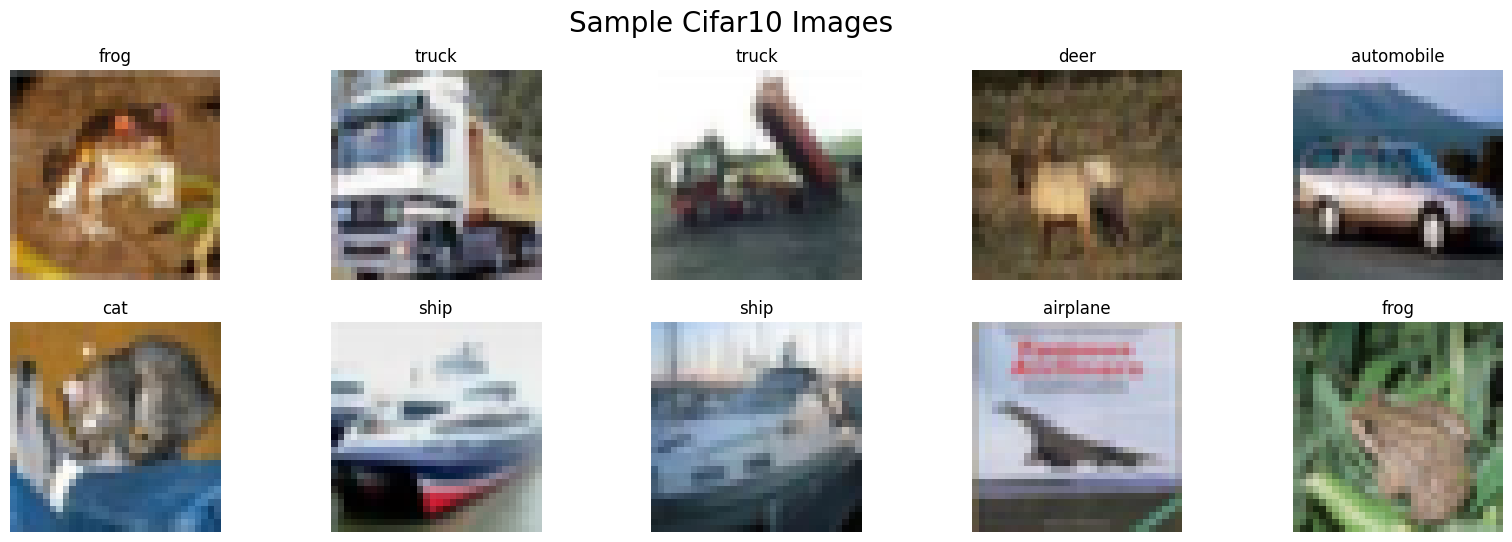

In [5]:
CIFAR_CLASS = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Load Cifar10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

data_train = [X_train, y_train]
data_test = [X_test, y_test]

# Display some sample images
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
for i, data in enumerate([data_train, data_test]):
    for j in range(5):
        axes[i][j].imshow(data[0][j], cmap='gray')
        axes[i][j].set_title(CIFAR_CLASS[data[1][j][0]])
        axes[i][j].axis('off')

plt.suptitle("Sample Cifar10 Images", fontsize=20)
plt.show()

In [ ]:
# Preprocess data
X_train_proc = X_train.reshape(X_train.shape[0], -1).astype('float32') / 255.0
y_train_proc = y_train.reshape(-1)
X_test_proc = X_test.reshape(X_test.shape[0], -1).astype('float32') / 255.0
y_test_proc = y_test.reshape(-1)

data = {
    "Training Images": (X_train, X_train_proc),
    "Training Labels": (y_train, y_train_proc),
    "Validation Images": (X_test, X_test_proc),
    "Validation Labels": (y_test, y_test_proc),
}

for key, (ori, proc) in data.items():
    print(f"Change {key}' shape from {ori.shape} to {proc.shape}, dtype: {proc.dtype}")

Change Training Images' shape from (50000, 32, 32, 3) to (50000, 3072), dtype: float32
Change Training Labels' shape from (50000, 1) to (50000,), dtype: uint8
Change Validation Images' shape from (10000, 32, 32, 3) to (10000, 3072), dtype: float32
Change Validation Labels' shape from (10000, 1) to (10000,), dtype: uint8


In [ ]:
# Create model
model = Sequential([
    Dense(128, activation='relu', input_dim=X_train_proc.shape[1]),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax'),
], name="mlp_object_classifier")

initial_weights = model.get_weights()
model.summary()

Model: "mlp_object_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 128)               393344    
                                                                 
 dense_7 (Dense)             (None, 32)                4128      
                                                                 
 dense_8 (Dense)             (None, 10)                330       
                                                                 
Total params: 397,802
Trainable params: 397,802
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# Reset weights
model.set_weights(initial_weights)

# Compile model
model.compile(optimizer="adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
mcp_save = ModelCheckpoint(f'{CKPT_PATH}/mlp_object_recognizer.keras', save_best_only=True, verbose=1, monitor='val_loss')

# Train model with history tracking
result = model.fit(
    X_train_proc, 
    y_train_proc, 
    epochs=50, 
    batch_size=512, 
    shuffle=True,
    validation_data=(X_test_proc, y_test_proc), 
    callbacks=[early_stopping, mcp_save],
)

Epoch 1/50
93/98 [===========================>..] - ETA: 0s - loss: 2.1047 - accuracy: 0.2120
Epoch 1: val_loss improved from inf to 1.93405, saving model to /app/checkpoints/mlp_object_recognizer.keras
98/98 [==============================] - 2s 14ms/step - loss: 2.0978 - accuracy: 0.2156 - val_loss: 1.9340 - val_accuracy: 0.2926
Epoch 2/50
93/98 [===========================>..] - ETA: 0s - loss: 1.8770 - accuracy: 0.3203
Epoch 2: val_loss improved from 1.93405 to 1.81833, saving model to /app/checkpoints/mlp_object_recognizer.keras
98/98 [==============================] - 1s 9ms/step - loss: 1.8758 - accuracy: 0.3215 - val_loss: 1.8183 - val_accuracy: 0.3426
Epoch 3/50
96/98 [============================>.] - ETA: 0s - loss: 1.7988 - accuracy: 0.3515
Epoch 3: val_loss improved from 1.81833 to 1.78630, saving model to /app/checkpoints/mlp_object_recognizer.keras
98/98 [==============================] - 1s 9ms/step - loss: 1.7985 - accuracy: 0.3512 - val_loss: 1.7863 - val_accuracy: 0.


Epoch 4: val_loss improved from 1.78630 to 1.73200, saving model to /app/checkpoints/mlp_object_recognizer.keras
98/98 [==============================] - 1s 9ms/step - loss: 1.7593 - accuracy: 0.3657 - val_loss: 1.7320 - val_accuracy: 0.3836
Epoch 5/50
95/98 [============================>.] - ETA: 0s - loss: 1.7167 - accuracy: 0.3857
Epoch 5: val_loss improved from 1.73200 to 1.69861, saving model to /app/checkpoints/mlp_object_recognizer.keras
98/98 [==============================] - 1s 15ms/step - loss: 1.7163 - accuracy: 0.3859 - val_loss: 1.6986 - val_accuracy: 0.3943
Epoch 6/50
97/98 [============================>.] - ETA: 0s - loss: 1.6838 - accuracy: 0.3995
Epoch 6: val_loss improved from 1.69861 to 1.67024, saving model to /app/checkpoints/mlp_object_recognizer.keras
98/98 [==============================] - 1s 9ms/step - loss: 1.6834 - accuracy: 0.3996 - val_loss: 1.6702 - val_accuracy: 0.4042
Epoch 7/50
95/98 [============================>.] - ETA: 0s - loss: 1.6580 - accurac

313/313 [==============================] - 1s 3ms/step - loss: 1.4340 - accuracy: 0.5004
Test Accuracy: 50.04%


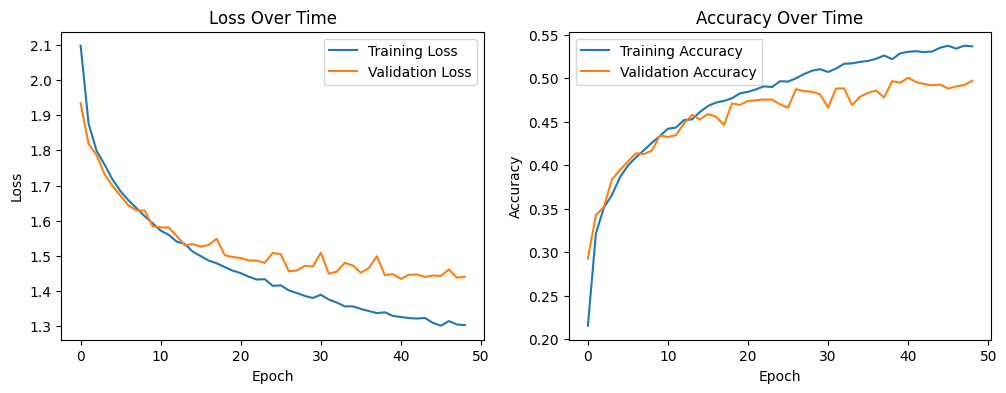

In [ ]:
# Evaluate model
model.load_weights(f'{CKPT_PATH}/mlp_object_recognizer.keras')
loss, accuracy = model.evaluate(X_test_proc, y_test_proc)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training history
generate_plot(result)

1/1 [==============================] - 1s 1s/step


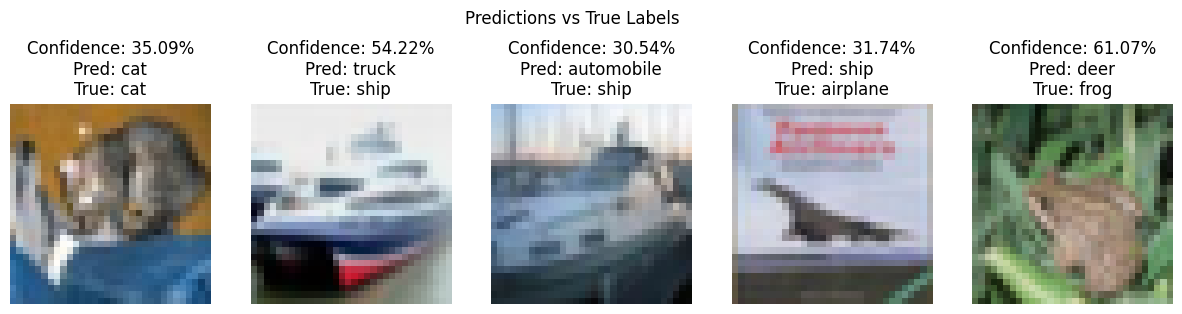

In [ ]:
# Predict on test set and visualize some results
model.load_weights(f'{CKPT_PATH}/mlp_object_recognizer.keras')
scores = model.predict(X_test_proc[:5])
predictions = np.argmax(scores, axis=1) # Get predicted class from the max confidence score
y_true = y_test_proc[:5]

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i in range(5):
    axes[i].imshow(X_test[i], cmap='gray')
    axes[i].set_title(f"Confidence: {scores[i][predictions[i]]*100:.2f}%\nPred: {CIFAR_CLASS[predictions[i]]}\nTrue: {CIFAR_CLASS[y_true[i]]}")
    axes[i].axis('off')
plt.suptitle("Predictions vs True Labels")
plt.show()

#### Dataset 2 (MNIST)

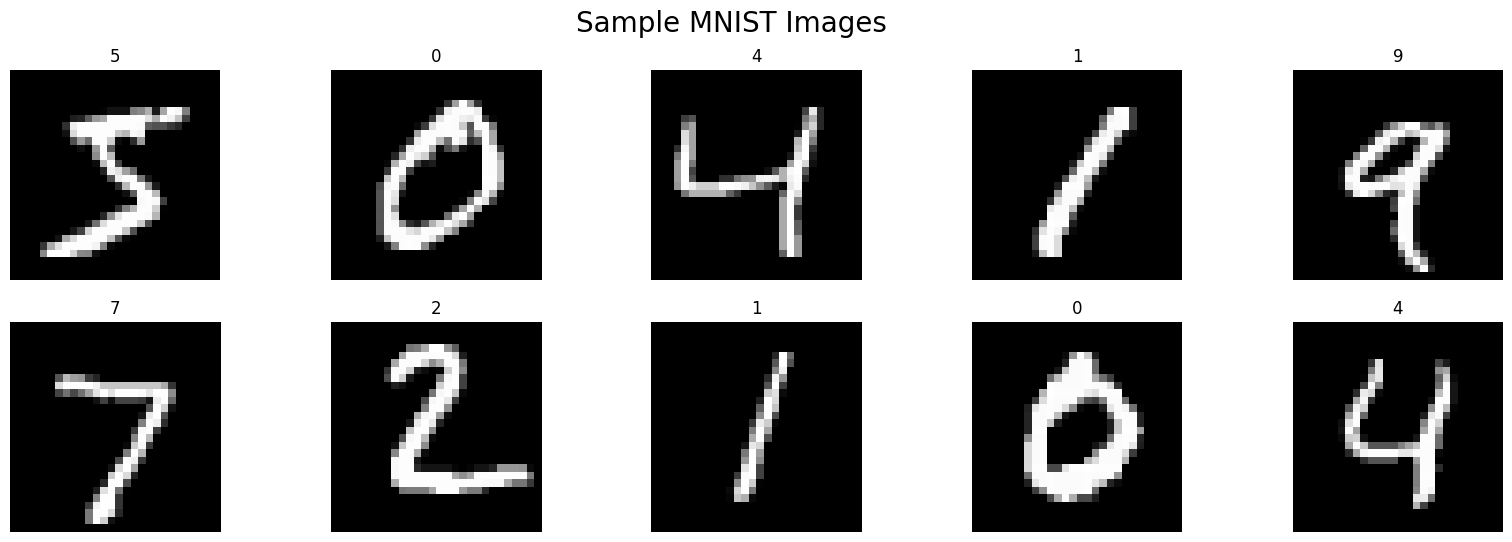

In [ ]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

data_train = [X_train, y_train]
data_test = [X_test, y_test]

# Display some sample images
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
for i, data in enumerate([data_train, data_test]):
    for j in range(5):
        axes[i][j].imshow(data[0][j], cmap='gray')
        axes[i][j].set_title(data[1][j])
        axes[i][j].axis('off')

plt.suptitle("Sample MNIST Images", fontsize=20)
plt.show()

In [ ]:
# Preprocess data
X_train_proc = X_train.reshape(X_train.shape[0], -1).astype('float32') / 255.0
X_test_proc = X_test.reshape(X_test.shape[0], -1).astype('float32') / 255.0

data = {
    "Training Images": (X_train, X_train_proc),
    "Training Labels": (y_train, y_train),
    "Validation Images": (X_test, X_test_proc),
    "Validation Labels": (y_test, y_test),
}

for key, (ori, proc) in data.items():
    print(f"Change {key}' shape from {ori.shape} to {proc.shape}, dtype: {proc.dtype}")

Change Training Images' shape from (60000, 28, 28) to (60000, 784), dtype: float32
Change Training Labels' shape from (60000,) to (60000,), dtype: uint8
Change Validation Images' shape from (10000, 28, 28) to (10000, 784), dtype: float32
Change Validation Labels' shape from (10000,) to (10000,), dtype: uint8


In [ ]:
# Create model
model = Sequential([
    Dense(128, activation='relu', input_dim=X_train_proc.shape[1]),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax'),
], name="mlp_digit_classifier")

initial_weights = model.get_weights()
model.summary()

Model: "mlp_digit_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_17 (Dense)            (None, 128)               100480    
                                                                 
 dense_18 (Dense)            (None, 32)                4128      
                                                                 
 dense_19 (Dense)            (None, 10)                330       
                                                                 
Total params: 104,938
Trainable params: 104,938
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# Reset weights
model.set_weights(initial_weights)

# Compile model
model.compile(optimizer="adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
mcp_save = ModelCheckpoint(f'{CKPT_PATH}/mlp_digit_recognizer.keras', save_best_only=True, verbose=1, monitor='val_loss')

# Train model with history tracking
result = model.fit(
    X_train_proc, 
    y_train, 
    epochs=50, 
    batch_size=512, 
    shuffle=True,
    validation_data=(X_test_proc, y_test), 
    callbacks=[early_stopping, mcp_save],
)

Epoch 1/50
117/118 [============================>.] - ETA: 0s - loss: 0.5664 - accuracy: 0.8488
Epoch 1: val_loss improved from inf to 0.24684, saving model to /app/checkpoints/mlp_digit_recognizer.keras
118/118 [==============================] - 2s 8ms/step - loss: 0.5658 - accuracy: 0.8489 - val_loss: 0.2468 - val_accuracy: 0.9304
Epoch 2/50
109/118 [==========================>...] - ETA: 0s - loss: 0.2142 - accuracy: 0.9387
Epoch 2: val_loss improved from 0.24684 to 0.17855, saving model to /app/checkpoints/mlp_digit_recognizer.keras
118/118 [==============================] - 1s 6ms/step - loss: 0.2122 - accuracy: 0.9391 - val_loss: 0.1786 - val_accuracy: 0.9481
Epoch 3/50
110/118 [==========================>...] - ETA: 0s - loss: 0.1611 - accuracy: 0.9540
Epoch 3: val_loss improved from 0.17855 to 0.14748, saving model to /app/checkpoints/mlp_digit_recognizer.keras
118/118 [==============================] - 2s 15ms/step - loss: 0.1591 - accuracy: 0.9547 - val_loss: 0.1475 - val_acc

111/118 [===========================>..] - ETA: 0s - loss: 0.0772 - accuracy: 0.9773
Epoch 7: val_loss improved from 0.10311 to 0.09917, saving model to /app/checkpoints/mlp_digit_recognizer.keras
118/118 [==============================] - 1s 6ms/step - loss: 0.0775 - accuracy: 0.9773 - val_loss: 0.0992 - val_accuracy: 0.9704
Epoch 8/50
108/118 [==========================>...] - ETA: 0s - loss: 0.0671 - accuracy: 0.9802
Epoch 8: val_loss improved from 0.09917 to 0.09614, saving model to /app/checkpoints/mlp_digit_recognizer.keras
118/118 [==============================] - 1s 6ms/step - loss: 0.0678 - accuracy: 0.9802 - val_loss: 0.0961 - val_accuracy: 0.9707
Epoch 9/50
111/118 [===========================>..] - ETA: 0s - loss: 0.0591 - accuracy: 0.9830
Epoch 9: val_loss improved from 0.09614 to 0.09074, saving model to /app/checkpoints/mlp_digit_recognizer.keras
118/118 [==============================] - 1s 6ms/step - loss: 0.0591 - accuracy: 0.9829 - val_loss: 0.0907 - val_accuracy: 0

313/313 [==============================] - 1s 2ms/step - loss: 0.0762 - accuracy: 0.9776
Test Accuracy: 97.76%


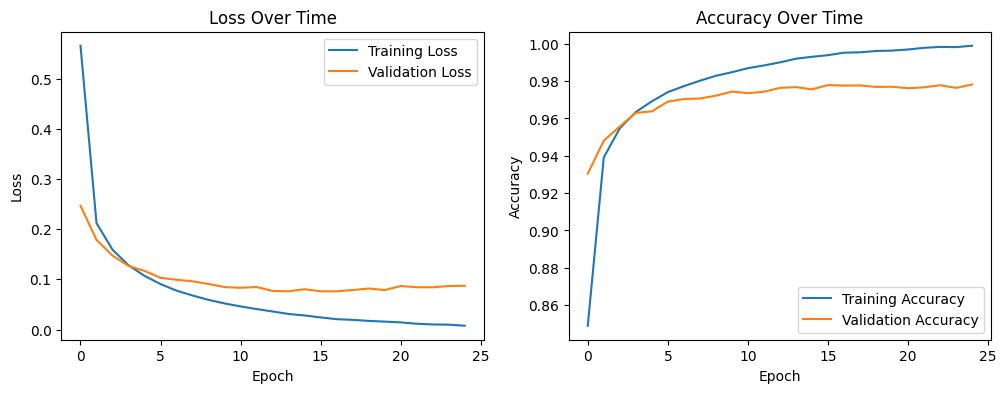

In [ ]:
# Evaluate model
model.load_weights(f'{CKPT_PATH}/mlp_digit_recognizer.keras')
loss, accuracy = model.evaluate(X_test_proc, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training history
generate_plot(result)

1/1 [==============================] - 0s 79ms/step


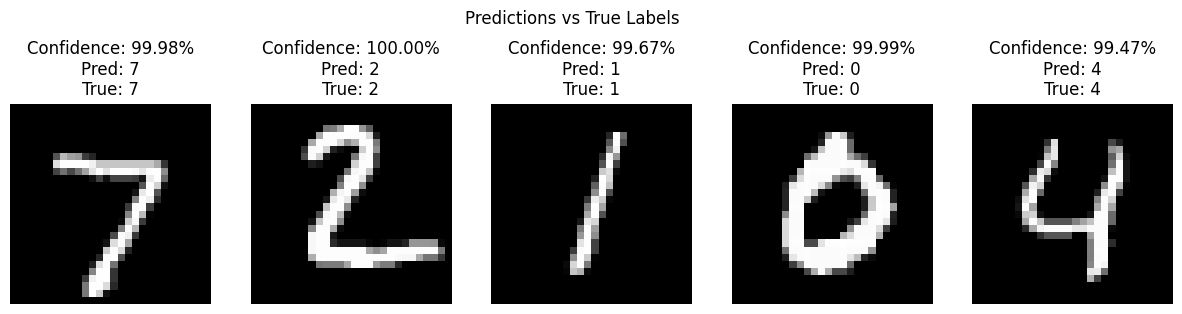

In [ ]:
# Predict on test set and visualize some results
model.load_weights(f'{CKPT_PATH}/mlp_digit_recognizer.keras')
scores = model.predict(X_test_proc[:5])
predictions = np.argmax(scores, axis=1) # Get predicted class from the max confidence score
y_true = y_test[:5]

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i in range(5):
    axes[i].imshow(X_test_proc[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"Confidence: {scores[i][predictions[i]]*100:.2f}%\nPred: {predictions[i]}\nTrue: {y_true[i]}")
    axes[i].axis('off')
plt.suptitle("Predictions vs True Labels")
plt.show()

<a id="2"></a>
## **2. Penerapan Convolutional Neural Netowrk (CNN): Penjelasan dan Studi Kasus**
---

<a id=21></a>
### **2.1 Konsep CNN**

Convolutional Neural Network (CNN) adalah jenis khusus dari neural networks yang
dirancang khusus untuk memproses data dengan struktur grid seperti gambar. CNN telah
sukses besar dalam berbagai aplikasi pengenalan gambar dan video.

__Struktur CNN__
1. __Input Layer:__ Layer ini terdiri dari neuron yang merepresentasikan setiap input fitur dalam data. Umumnya berupa gambar berbentuk N (Total / Batch image), H (Height), W (Width), C (Channel).
2. __Convolutional Layer:__ Layer konvolusi adalah elemen inti dari CNN. Dalam layer ini, beberapa filter digunakan untuk melakukan operasi konvolusi pada input. Hasil dari operasi ini disebut feature map atau activation map.
3. __Pooling Layer:__ Pooling layer bertujuan untuk mengurangi dimensionalitas data. Ada berbagai teknik pooling, termasuk max pooling, average pooling, dan sum pooling.
4. __Fully Connected Layer:__ Fully connected layer menghubungkan setiap neuron di layer sebelumnya ke setiap neuron di layer berikutnya, mirip dengan apa yang kita lihat di MLP. Biasanya, fully connected layer ditempatkan di akhir arsitektur CNN, dan bertugas untuk menghasilkan prediksi akhir model.

__Fungsi Aktivasi dalam CNN__

ReLU (Rectified Linear Unit) adalah fungsi aktivasi yang paling sering digunakan dalam
CNN. Fungsi ini mampu mempercepat konvergensi jaringan neural dibandingkan dengan
sigmoid atau tanh.

__Proses Training CNN__

Proses pelatihan CNN serupa dengan MLP. Kami menggunakan metode seperti
backpropagation dan algoritma optimasi seperti Adam atau SGD untuk melatih model kami.
Kita menghitung loss dengan fungsi loss seperti cross-entropy, dan mengupdate
bobot dan bias berdasarkan gradien loss dari proses backward pass.

<a id=22></a>
### **2.2 Studi Kasus**
Alih-alih menggunakan MLP yang hanya memiliki layer sederhana, kita akan coba membuat model CNN pakai library keras dari TensorFlow untuk mengklasifikasi objek dan digit dengan hasil prediksi yang lebih baik. Berikut adalah kode yang kita perlukan:

#### Dataset 1 (CIFAR10)

Training dataset has 50000 examples
Validation dataset has 10000 examples


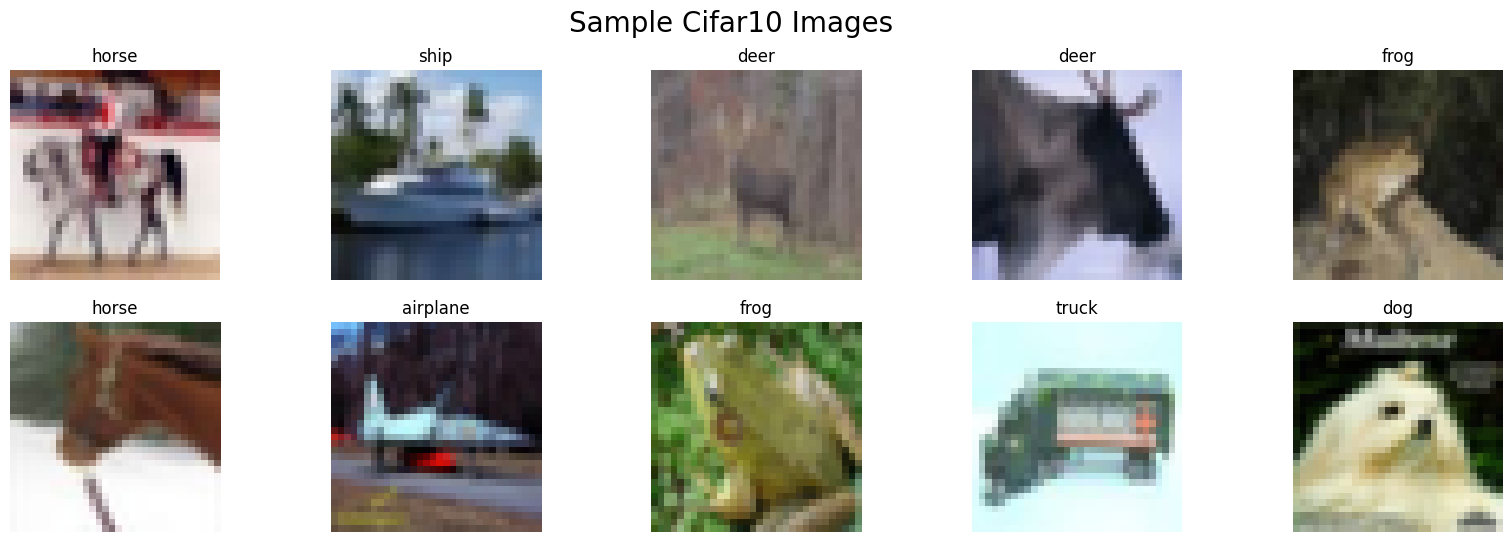

In [200]:
# Load Cifar10 dataset
(train_ds, val_ds), info = tfds.load(
    "cifar10",
    split=["train", "test"],
    as_supervised=True,
    with_info=True,
    data_dir="/app/datasets/tfds",
)

CIFAR_CLASS = info.features["label"].names
print(f"Training dataset has {info.splits['train'].num_examples} examples")
print(f"Validation dataset has {info.splits['test'].num_examples} examples")

# Display some sample images
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
for i, data in enumerate([
    list(train_ds.take(5)), list(val_ds.take(5)),
]):
    for j in range(5):
        axes[i][j].imshow(data[j][0], cmap='gray')
        axes[i][j].set_title(CIFAR_CLASS[data[j][1].numpy()])
        axes[i][j].axis('off')

plt.suptitle("Sample Cifar10 Images", fontsize=20)
plt.show()

In [201]:
def get_transform(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

BATCH_SIZE = 512
DATA_LEN = info.splits["train"].num_examples

# Preprocess data
train_ds_proc = (
    train_ds
    .map(get_transform, 
         num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .shuffle(DATA_LEN, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds_proc = (
    val_ds
    .map(get_transform, 
         num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

for data in [train_ds_proc, val_ds_proc]:
    spec = data.element_spec
    print(f"Images of training dataset have shape: {spec[0].shape}, dtype: {spec[0].dtype.name}")
    print(f"Labels of training dataset have shape: {spec[1].shape}, dtype: {spec[1].dtype.name}")

# None in the first index means batch size

Images of training dataset have shape: (None, 32, 32, 3), dtype: float32
Labels of training dataset have shape: (None,), dtype: int64
Images of training dataset have shape: (None, 32, 32, 3), dtype: float32
Labels of training dataset have shape: (None,), dtype: int64


In [ ]:
# Create model
model = Sequential([
    layers.Input(shape=train_ds_proc.element_spec[0].shape[1:]),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    Flatten(),
    
    # Head
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
], name="cnn_object_classifier")

initial_weights = model.get_weights()
model.summary()

Model: "cnn_object_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_12 (Conv2D)          (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d_12 (MaxPoolin  (None, 16, 16, 32)       0         
 g2D)                                                            
                                                                 
 dropout_12 (Dropout)        (None, 16, 16, 32)        0         
                                                                 
 conv2d_13 (Conv2D)          (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_13 (MaxPoolin  (None, 8, 8, 64)         0         
 g2D)                                                            
                                                                 
 dropout_13 (Dropout)        (None, 8, 8, 64)

In [203]:
# Reset weights
model.set_weights(initial_weights)

# Compile model
model.compile(optimizer="adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
mcp_save = ModelCheckpoint(f'{CKPT_PATH}/cnn_object_recognizer.keras', save_best_only=True, verbose=1, monitor='val_loss')

# Train model with history tracking
result = model.fit(
    train_ds_proc,
    epochs=50, 
    validation_data=val_ds_proc, 
    callbacks=[early_stopping, mcp_save],
)

Epoch 1/50


2026-02-15 18:45:17.555386: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:1014] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape incnn_object_classifier/dropout_12/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


97/98 [============================>.] - ETA: 0s - loss: 1.8969 - accuracy: 0.3063
Epoch 1: val_loss improved from inf to 1.74840, saving model to /app/checkpoints/cnn_object_recognizer.keras
98/98 [==============================] - 6s 27ms/step - loss: 1.8950 - accuracy: 0.3072 - val_loss: 1.7484 - val_accuracy: 0.3696
Epoch 2/50
97/98 [============================>.] - ETA: 0s - loss: 1.5303 - accuracy: 0.4451
Epoch 2: val_loss improved from 1.74840 to 1.43436, saving model to /app/checkpoints/cnn_object_recognizer.keras
98/98 [==============================] - 2s 20ms/step - loss: 1.5299 - accuracy: 0.4451 - val_loss: 1.4344 - val_accuracy: 0.4854
Epoch 3/50
97/98 [============================>.] - ETA: 0s - loss: 1.3783 - accuracy: 0.5049
Epoch 3: val_loss improved from 1.43436 to 1.27532, saving model to /app/checkpoints/cnn_object_recognizer.keras
98/98 [==============================] - 2s 20ms/step - loss: 1.3779 - accuracy: 0.5051 - val_loss: 1.2753 - val_accuracy: 0.5462
Epoc

20/20 [==============================] - 0s 7ms/step - loss: 0.6318 - accuracy: 0.7802
Test Accuracy: 78.02%


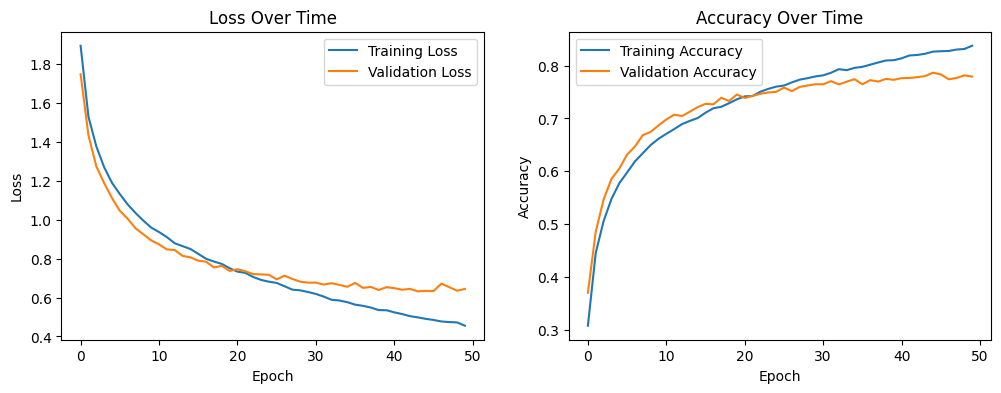

In [204]:
# Evaluate model
model.load_weights(f'{CKPT_PATH}/cnn_object_recognizer.keras')
loss, accuracy = model.evaluate(val_ds_proc)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training history
generate_plot(result)

1/1 [==============================] - 0s 202ms/step


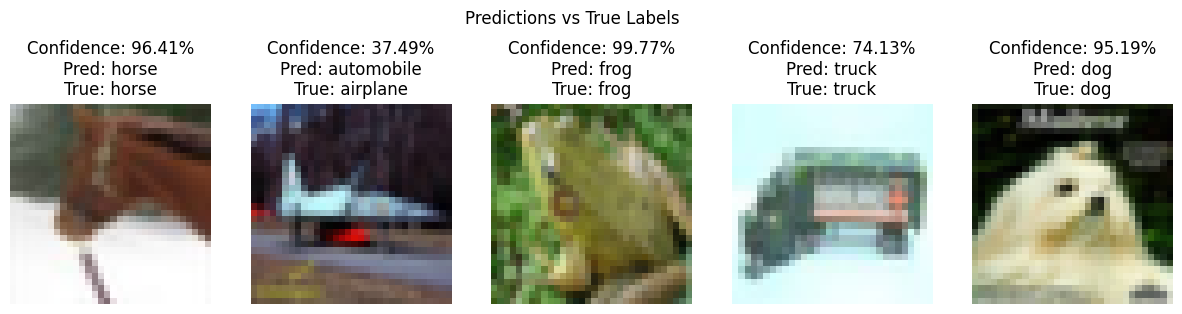

In [ ]:
X_sample, y_sample = next(
    val_ds_proc.unbatch().batch(5).as_numpy_iterator()
)

# Predict on test set and visualize some results
model.load_weights(f'{CKPT_PATH}/cnn_object_recognizer.keras')
scores = model.predict(X_sample)
predictions = np.argmax(scores, axis=1) # Get predicted class from the max confidence score

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i in range(5):
    axes[i].imshow(X_sample[i], cmap='gray')
    axes[i].set_title(f"Confidence: {scores[i][predictions[i]]*100:.2f}%\nPred: {CIFAR_CLASS[predictions[i]]}\nTrue: {CIFAR_CLASS[y_sample[i]]}")
    axes[i].axis('off')
plt.suptitle("Predictions vs True Labels")
plt.show()

#### Dataset 2 (MNIST)

Training dataset has 60000 examples
Validation dataset has 10000 examples


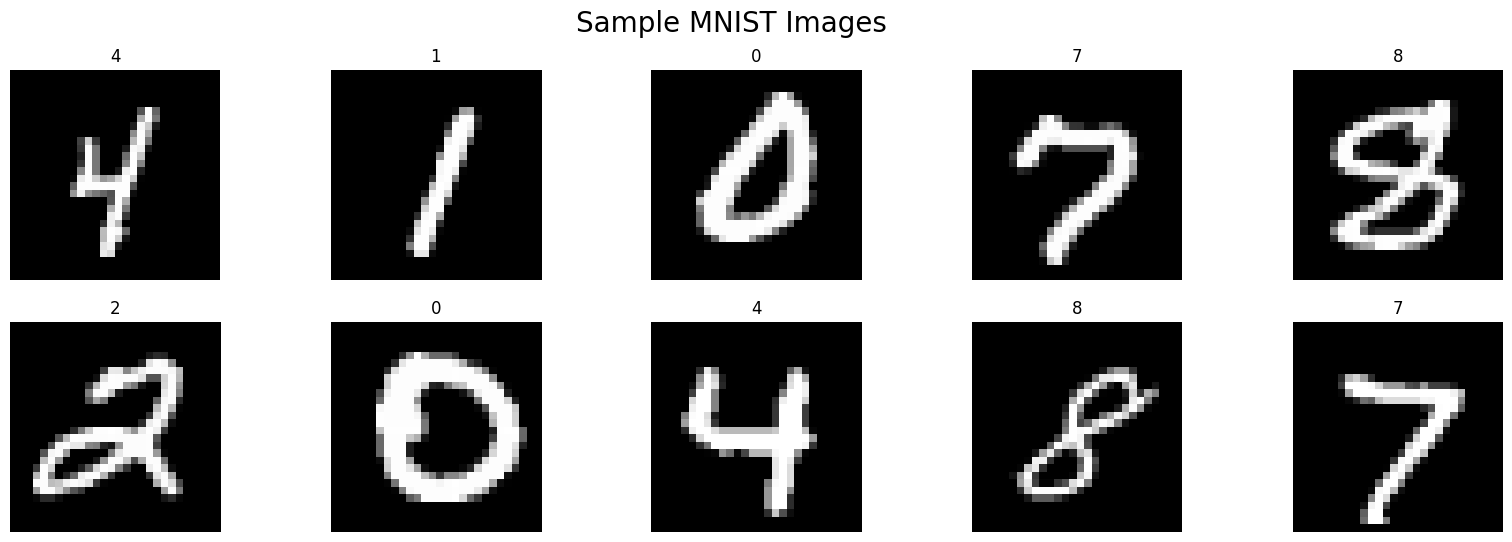

In [32]:
# Load MNIST dataset
(train_ds, val_ds), info = tfds.load(
    "mnist",
    split=["train", "test"],
    as_supervised=True,
    with_info=True,
    data_dir="/app/datasets/tfds",
)

print(f"Training dataset has {info.splits['train'].num_examples} examples")
print(f"Validation dataset has {info.splits['test'].num_examples} examples")

# Display some sample images
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
for i, data in enumerate([
    list(train_ds.take(5)), list(val_ds.take(5)),
]):
    for j in range(5):
        axes[i][j].imshow(data[j][0], cmap='gray')
        axes[i][j].set_title(data[j][1].numpy())
        axes[i][j].axis('off')

plt.suptitle("Sample MNIST Images", fontsize=20)
plt.show()

In [33]:
def get_transform(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

BATCH_SIZE = 512
DATA_LEN = info.splits["train"].num_examples

# Preprocess data
train_ds_proc = (
    train_ds
    .map(get_transform, 
         num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .shuffle(DATA_LEN, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds_proc = (
    val_ds
    .map(get_transform, 
         num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

for data in [train_ds_proc, val_ds_proc]:
    spec = data.element_spec
    print(f"Images of training dataset have shape: {spec[0].shape}, dtype: {spec[0].dtype.name}")
    print(f"Labels of training dataset have shape: {spec[1].shape}, dtype: {spec[1].dtype.name}")

# None in the first index means batch size

Images of training dataset have shape: (None, 28, 28, 1), dtype: float32
Labels of training dataset have shape: (None,), dtype: int64
Images of training dataset have shape: (None, 28, 28, 1), dtype: float32
Labels of training dataset have shape: (None,), dtype: int64


In [ ]:
# Create model
model = Sequential([
    layers.Input(shape=train_ds_proc.element_spec[0].shape[1:]),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    Flatten(),
    
    # Head
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
], name="cnn_digit_classifier")

initial_weights = model.get_weights()
model.summary()

Model: "cnn_digit_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                                                 
 dropout_3 (Dropout)         (None, 14, 14, 32)        0         
                                                                 
 conv2d_4 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 7, 7, 64)         0         
 2D)                                                             
                                                                 
 dropout_4 (Dropout)         (None, 7, 7, 64) 

In [35]:
# Reset weights
model.set_weights(initial_weights)

# Compile model
model.compile(optimizer="adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
mcp_save = ModelCheckpoint(f'{CKPT_PATH}/cnn_digit_recognizer.keras', save_best_only=True, verbose=1, monitor='val_loss')

# Train model with history tracking
result = model.fit(
    train_ds_proc,
    epochs=30, 
    validation_data=val_ds_proc, 
    callbacks=[early_stopping, mcp_save],
)

Epoch 1/30


2026-02-15 13:50:57.746692: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:1014] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape incnn_digit_classifier/dropout_3/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


118/118 [==============================] - ETA: 0s - loss: 0.6042 - accuracy: 0.8019
Epoch 1: val_loss improved from inf to 0.11237, saving model to /app/checkpoints/cnn_digit_recognizer.keras
118/118 [==============================] - 6s 23ms/step - loss: 0.6042 - accuracy: 0.8019 - val_loss: 0.1124 - val_accuracy: 0.9616
Epoch 2/30
117/118 [============================>.] - ETA: 0s - loss: 0.1356 - accuracy: 0.9576
Epoch 2: val_loss improved from 0.11237 to 0.05712, saving model to /app/checkpoints/cnn_digit_recognizer.keras
118/118 [==============================] - 2s 15ms/step - loss: 0.1356 - accuracy: 0.9577 - val_loss: 0.0571 - val_accuracy: 0.9829
Epoch 3/30
117/118 [============================>.] - ETA: 0s - loss: 0.0960 - accuracy: 0.9705
Epoch 3: val_loss improved from 0.05712 to 0.04388, saving model to /app/checkpoints/cnn_digit_recognizer.keras
118/118 [==============================] - 2s 15ms/step - loss: 0.0961 - accuracy: 0.9705 - val_loss: 0.0439 - val_accuracy: 0.

Epoch 4/30
117/118 [============================>.] - ETA: 0s - loss: 0.0734 - accuracy: 0.9761
Epoch 4: val_loss improved from 0.04388 to 0.03819, saving model to /app/checkpoints/cnn_digit_recognizer.keras
118/118 [==============================] - 2s 15ms/step - loss: 0.0734 - accuracy: 0.9762 - val_loss: 0.0382 - val_accuracy: 0.9875
Epoch 5/30
117/118 [============================>.] - ETA: 0s - loss: 0.0637 - accuracy: 0.9806
Epoch 5: val_loss improved from 0.03819 to 0.03072, saving model to /app/checkpoints/cnn_digit_recognizer.keras
118/118 [==============================] - 2s 15ms/step - loss: 0.0637 - accuracy: 0.9806 - val_loss: 0.0307 - val_accuracy: 0.9893
Epoch 6/30
117/118 [============================>.] - ETA: 0s - loss: 0.0552 - accuracy: 0.9826
Epoch 6: val_loss improved from 0.03072 to 0.02924, saving model to /app/checkpoints/cnn_digit_recognizer.keras
118/118 [==============================] - 2s 15ms/step - loss: 0.0552 - accuracy: 0.9826 - val_loss: 0.0292 - v

20/20 [==============================] - 0s 5ms/step - loss: 0.0168 - accuracy: 0.9935
Test Accuracy: 99.35%


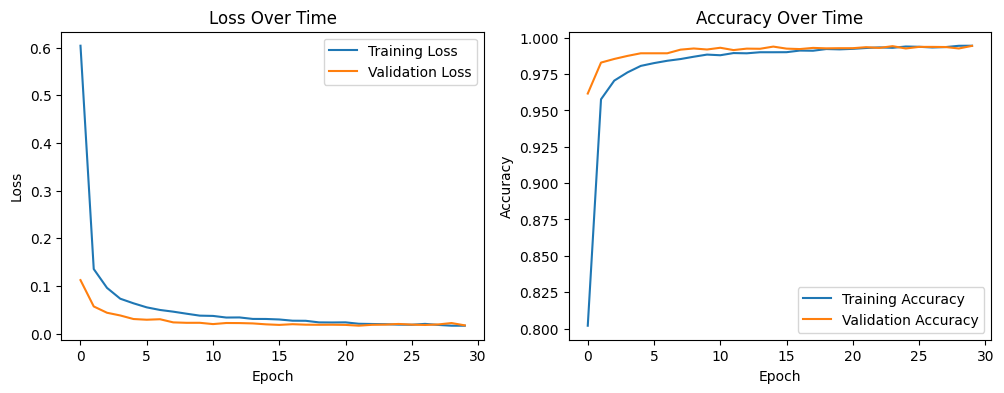

In [36]:
# Evaluate model
model.load_weights(f'{CKPT_PATH}/cnn_digit_recognizer.keras')
loss, accuracy = model.evaluate(val_ds_proc)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training history
generate_plot(result)

1/1 [==============================] - 0s 97ms/step


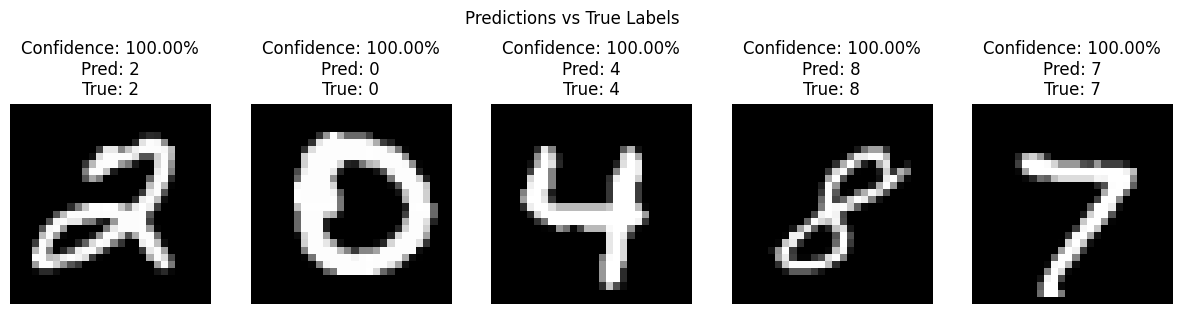

In [ ]:
X_sample, y_sample = next(
    val_ds_proc.unbatch().batch(5).as_numpy_iterator()
)

# Predict on test set and visualize some results
model.load_weights(f'{CKPT_PATH}/cnn_digit_recognizer.keras')
scores = model.predict(X_sample)
predictions = np.argmax(scores, axis=1) # Get predicted class from the max confidence score

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i in range(5):
    axes[i].imshow(X_sample[i], cmap='gray')
    axes[i].set_title(f"Confidence: {scores[i][predictions[i]]*100:.2f}%\nPred: {predictions[i]}\nTrue: {y_sample[i]}")
    axes[i].axis('off')
plt.suptitle("Predictions vs True Labels")
plt.show()

<a id="3"></a>
## **3. Penerapan Transfer Learning: Penjelasan dan Studi Kasus**
---

<a id=31></a>
### **3.1 Konsep Transfer Learning**

Salah satu metode dalam melakukan tuning model AI yaitu menggunakan transfer learning. Cara kerjanya adalah mentransferkan ilmu (weight) dari dataset yang lebih besar ke modelnya, sehingga hasil prediksi pada dataset yang dituju bisa jauh lebih baik lagi.

<a id=32></a>
### **3.2 Studi Kasus**
Berikut adalah studi kasusnya menggunakan dataset CIFAR10 dengan pretrained weights dari Tiny-Imagenet:

#### Prepare Data

Training dataset has 50000 examples
Validation dataset has 10000 examples


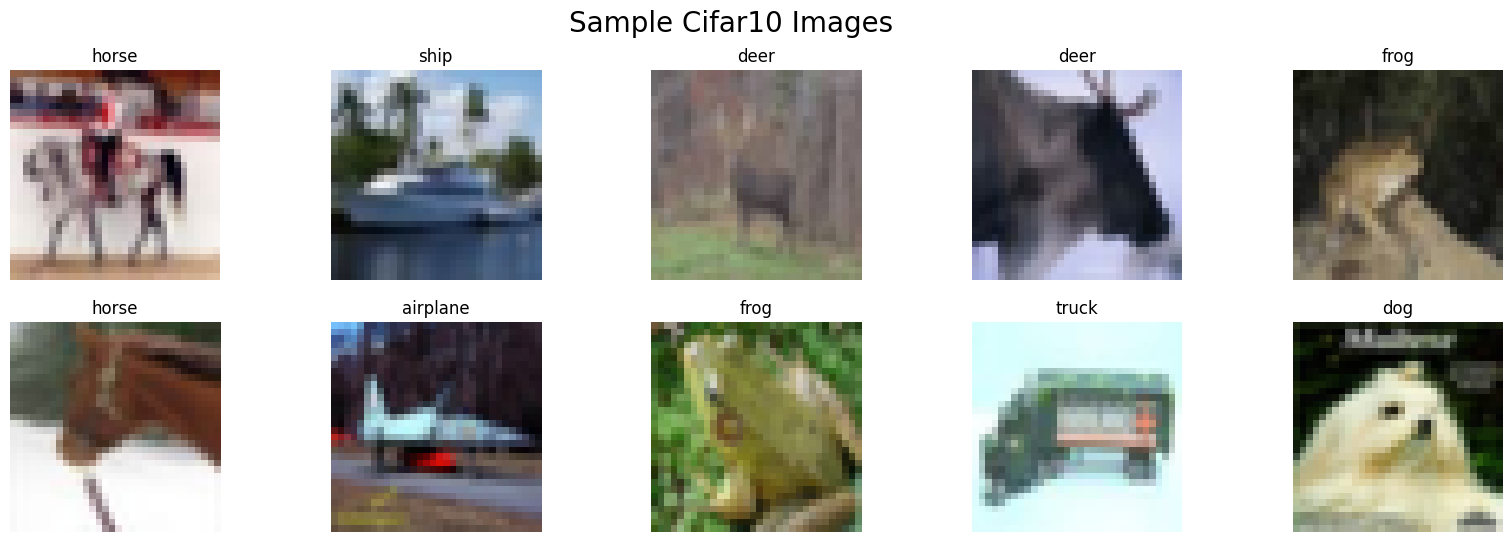

In [4]:
# Load Cifar10 dataset
(train_ds, val_ds), info = tfds.load(
    "cifar10",
    split=["train", "test"],
    as_supervised=True,
    with_info=True,
    data_dir="/app/datasets/tfds",
)

CIFAR_CLASS = info.features["label"].names
print(f"Training dataset has {info.splits['train'].num_examples} examples")
print(f"Validation dataset has {info.splits['test'].num_examples} examples")

# Display some sample images
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
for i, data in enumerate([
    list(train_ds.take(5)), list(val_ds.take(5)),
]):
    for j in range(5):
        axes[i][j].imshow(data[j][0], cmap='gray')
        axes[i][j].set_title(CIFAR_CLASS[data[j][1].numpy()])
        axes[i][j].axis('off')

plt.suptitle("Sample Cifar10 Images", fontsize=20)
plt.show()

In [207]:
from functools import partial

def get_transform(image, label, img_size=224):
    image = tf.image.resize(image, (img_size, img_size))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

IMG_SIZE = 32
BATCH_SIZE = 512
DATA_LEN = info.splits["train"].num_examples

# Preprocess data
train_ds_proc = (
    train_ds
    .map(partial(get_transform, img_size=IMG_SIZE), 
         num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .shuffle(DATA_LEN, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds_proc = (
    val_ds
    .map(partial(get_transform, img_size=IMG_SIZE), 
         num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

for data in [train_ds_proc, val_ds_proc]:
    spec = data.element_spec
    print(f"Images of training dataset have shape: {spec[0].shape}, dtype: {spec[0].dtype.name}")
    print(f"Labels of training dataset have shape: {spec[1].shape}, dtype: {spec[1].dtype.name}")

# None in the first index means batch size

Images of training dataset have shape: (None, 32, 32, 3), dtype: float32
Labels of training dataset have shape: (None,), dtype: int64
Images of training dataset have shape: (None, 32, 32, 3), dtype: float32
Labels of training dataset have shape: (None,), dtype: int64


#### Finetune Model

In [ ]:
# Create model
model = Sequential([
    layers.Input(shape=train_ds_proc.element_spec[0].shape[1:], name="input_layer"),
    
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name="conv1"),
    layers.MaxPooling2D((2, 2), name="pool1"),
    layers.Dropout(0.3, name="drop1"),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name="conv2"),
    layers.MaxPooling2D((2, 2), name="pool2"),
    layers.Dropout(0.3, name="drop2"),
    
    layers.Conv2D(128, (3, 3), activation='relu', padding='same', name="conv3"),
    layers.MaxPooling2D((2, 2), name="pool3"),
    layers.Dropout(0.3, name="drop3"),
    
    layers.GlobalAveragePooling2D(name="gap"),

    # Head
    Dense(128, activation='relu', name="fc1"),
    Dense(10, activation='softmax', name="output_layer")
], name="fine_cnn_object_classifier")

# Load pretrained weights and freeze body layers
model.load_weights(
    f"{CKPT_PATH}/cnn_object_recognizer_timagenet.keras", 
    by_name=True, 
    skip_mismatch=True)

initial_weights = model.get_weights()
model.summary()

Model: "fine_cnn_object_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1 (Conv2D)              (None, 32, 32, 32)        896       
                                                                 
 pool1 (MaxPooling2D)        (None, 16, 16, 32)        0         
                                                                 
 drop1 (Dropout)             (None, 16, 16, 32)        0         
                                                                 
 conv2 (Conv2D)              (None, 16, 16, 64)        18496     
                                                                 
 pool2 (MaxPooling2D)        (None, 8, 8, 64)          0         
                                                                 
 drop2 (Dropout)             (None, 8, 8, 64)          0         
                                                                 
 conv3 (Conv2D)              (None, 8, 8

In [188]:
# Reset weights
model.set_weights(initial_weights)

# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
mcp_save = ModelCheckpoint(f'{CKPT_PATH}/fine_cnn_object_recognizer.keras', save_best_only=True, verbose=1, monitor='val_loss')

# Train model with history tracking
result = model.fit(
    train_ds_proc,
    epochs=150, 
    validation_data=val_ds_proc, 
    callbacks=[early_stopping, mcp_save],
)

Epoch 1/150


2026-02-15 18:34:57.225288: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:1014] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infine_cnn_object_classifier/drop1/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


97/98 [============================>.] - ETA: 0s - loss: 1.6154 - accuracy: 0.4145
Epoch 1: val_loss improved from inf to 1.25739, saving model to /app/checkpoints/fine_cnn_object_recognizer.keras
98/98 [==============================] - 6s 28ms/step - loss: 1.6130 - accuracy: 0.4156 - val_loss: 1.2574 - val_accuracy: 0.5450
Epoch 2/150
97/98 [============================>.] - ETA: 0s - loss: 1.1846 - accuracy: 0.5754
Epoch 2: val_loss improved from 1.25739 to 1.04768, saving model to /app/checkpoints/fine_cnn_object_recognizer.keras
98/98 [==============================] - 2s 20ms/step - loss: 1.1843 - accuracy: 0.5755 - val_loss: 1.0477 - val_accuracy: 0.6275
Epoch 3/150
97/98 [============================>.] - ETA: 0s - loss: 1.0880 - accuracy: 0.6097
Epoch 3: val_loss improved from 1.04768 to 1.00832, saving model to /app/checkpoints/fine_cnn_object_recognizer.keras
98/98 [==============================] - 2s 20ms/step - loss: 1.0875 - accuracy: 0.6100 - val_loss: 1.0083 - val_accu

20/20 [==============================] - 0s 7ms/step - loss: 0.5660 - accuracy: 0.8027
Test Accuracy: 80.27%


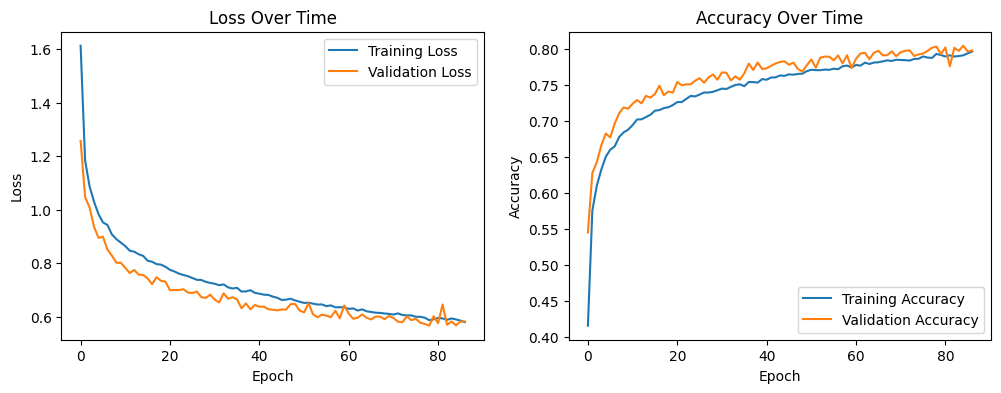

In [189]:
# Evaluate model
model.load_weights(f'{CKPT_PATH}/fine_cnn_object_recognizer.keras')
loss, accuracy = model.evaluate(val_ds_proc)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training history
generate_plot(result)

1/1 [==============================] - 0s 85ms/step


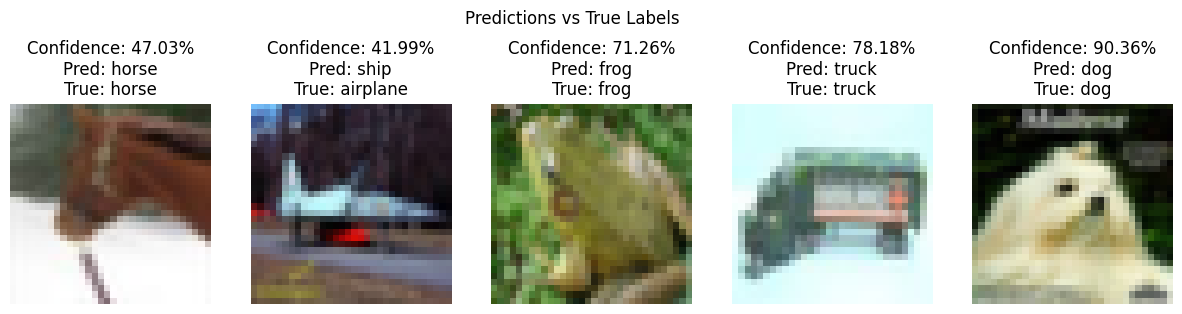

In [ ]:
X_sample, y_sample = next(
    val_ds_proc.unbatch().batch(5).as_numpy_iterator()
)

# Predict on test set and visualize some results
model.load_weights(f'{CKPT_PATH}/fine_cnn_object_recognizer.keras')
scores = model.predict(X_sample)
predictions = np.argmax(scores, axis=1) # Get predicted class from the max confidence score

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i in range(5):
    axes[i].imshow(X_sample[i], cmap='gray')
    axes[i].set_title(f"Confidence: {scores[i][predictions[i]]*100:.2f}%\nPred: {CIFAR_CLASS[predictions[i]]}\nTrue: {CIFAR_CLASS[y_sample[i]]}")
    axes[i].axis('off')
plt.suptitle("Predictions vs True Labels")
plt.show()

#### EfficientNet

In [ ]:
# Load Cifar10 dataset
(train_ds, val_ds), info = tfds.load(
    "cifar10",
    split=["train", "test"],
    as_supervised=True,
    with_info=True,
    data_dir="/app/datasets/tfds",
)

CIFAR_CLASS = info.features["label"].names
print(f"Training dataset has {info.splits['train'].num_examples} examples")
print(f"Validation dataset has {info.splits['test'].num_examples} examples")

# Display some sample images
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
for i, data in enumerate([
    list(train_ds.take(5)), list(val_ds.take(5)),
]):
    for j in range(5):
        axes[i][j].imshow(data[j][0], cmap='gray')
        axes[i][j].set_title(CIFAR_CLASS[data[j][1].numpy()])
        axes[i][j].axis('off')

plt.suptitle("Sample Cifar10 Images", fontsize=20)
plt.show()

In [14]:
from functools import partial

def get_transform(image, label, img_size=224):
    image = tf.image.resize(image, (img_size, img_size))
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    return image, label

IMG_SIZE = 32
BATCH_SIZE = 512
DATA_LEN = info.splits["train"].num_examples

# Preprocess data
train_ds_proc = (
    train_ds
    .map(partial(get_transform, img_size=IMG_SIZE), 
         num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .shuffle(DATA_LEN, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds_proc = (
    val_ds
    .map(partial(get_transform, img_size=IMG_SIZE), 
         num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

for data in [train_ds_proc, val_ds_proc]:
    spec = data.element_spec
    print(f"Images of training dataset have shape: {spec[0].shape}, dtype: {spec[0].dtype.name}")
    print(f"Labels of training dataset have shape: {spec[1].shape}, dtype: {spec[1].dtype.name}")

# None in the first index means batch size

Images of training dataset have shape: (None, 32, 32, 3), dtype: float32
Labels of training dataset have shape: (None,), dtype: int64
Images of training dataset have shape: (None, 32, 32, 3), dtype: float32
Labels of training dataset have shape: (None,), dtype: int64


In [ ]:
base = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base.trainable = False

# Create model
model = Sequential([
    layers.Input(shape=train_ds_proc.element_spec[0].shape[1:], name="input_layer"),
    
    base,

    layers.GlobalAveragePooling2D(name="gap"),
    
    # Head
    # Dense(128, activation='relu', name="fc1"),
    Dense(10, activation='softmax', name="output_layer")
], name="efficientnet_object_classifier")

initial_weights = model.get_weights()
model.summary()

Model: "efficientnet_object_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetv2-b0 (Function  (None, 1, 1, 1280)       5919312   
 al)                                                             
                                                                 
 gap (GlobalAveragePooling2D  (None, 1280)             0         
 )                                                               
                                                                 
 output_layer (Dense)        (None, 10)                12810     
                                                                 
Total params: 5,932,122
Trainable params: 12,810
Non-trainable params: 5,919,312
_________________________________________________________________


In [16]:
# Reset weights
model.set_weights(initial_weights)

# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
mcp_save = ModelCheckpoint(f'{CKPT_PATH}/efficientnet_object_recognizer.keras', save_best_only=True, verbose=1, monitor='val_loss')

# Train model with history tracking
result = model.fit(
    train_ds_proc,
    epochs=150, 
    validation_data=val_ds_proc, 
    callbacks=[early_stopping, mcp_save],
)

Epoch 1/150
97/98 [============================>.] - ETA: 0s - loss: 1.8753 - accuracy: 0.3992
Epoch 1: val_loss improved from inf to 1.57018, saving model to /app/checkpoints/efficientnet_object_recognizer.keras
98/98 [==============================] - 12s 68ms/step - loss: 1.8737 - accuracy: 0.3997 - val_loss: 1.5702 - val_accuracy: 0.4941
Epoch 2/150
97/98 [============================>.] - ETA: 0s - loss: 1.4919 - accuracy: 0.5182
Epoch 2: val_loss improved from 1.57018 to 1.38188, saving model to /app/checkpoints/efficientnet_object_recognizer.keras
98/98 [==============================] - 5s 46ms/step - loss: 1.4911 - accuracy: 0.5185 - val_loss: 1.3819 - val_accuracy: 0.5409
Epoch 3/150
97/98 [============================>.] - ETA: 0s - loss: 1.3668 - accuracy: 0.5490
Epoch 3: val_loss improved from 1.38188 to 1.29851, saving model to /app/checkpoints/efficientnet_object_recognizer.keras
98/98 [==============================] - 4s 45ms/step - loss: 1.3665 - accuracy: 0.5490 - va

20/20 [==============================] - 1s 33ms/step - loss: 1.0115 - accuracy: 0.6504
Test Accuracy: 65.04%


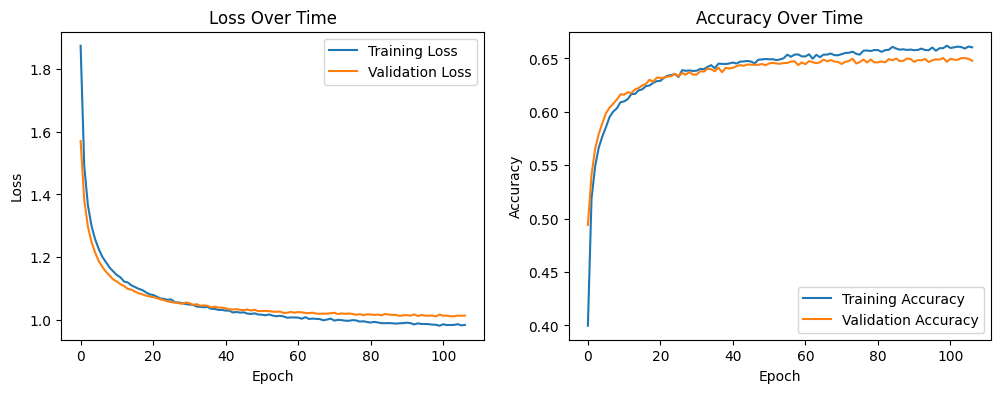

In [17]:
# Evaluate model
model.load_weights(f'{CKPT_PATH}/efficientnet_object_recognizer.keras')
loss, accuracy = model.evaluate(val_ds_proc)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training history
generate_plot(result)

#### Get Pretrained Weight (Tiny ImageNet)

In [ ]:
# !pip install git+https://git.ece.iastate.edu/teaching/cpre487_587/tiny-imagenet-tfds.git

  Cloning https://git.ece.iastate.edu/teaching/cpre487_587/tiny-imagenet-tfds.git to /tmp/pip-req-build-8ehyxqrs
  Running command git clone --filter=blob:none --quiet https://git.ece.iastate.edu/teaching/cpre487_587/tiny-imagenet-tfds.git /tmp/pip-req-build-8ehyxqrs
  Resolved https://git.ece.iastate.edu/teaching/cpre487_587/tiny-imagenet-tfds.git to commit 425498e42956f129a388b17fbb646c1a5795f03b
  Preparing metadata (setup.py) ... done
  Created wheel for tiny-imagenet-tfds: filename=tiny_imagenet_tfds-0.2.0-py3-none-any.whl size=8231 sha256=89ed533fe67b2ad68a38cc60d6e3ce2707b0374f1e5cb2fb7a9681ff241084f4
  Stored in directory: /tmp/pip-ephem-wheel-cache-7gp25sqa/wheels/f6/df/63/370d7c776a921f7f70c21ae05e8ae26e644df82488d38dbd21
Successfully built tiny-imagenet-tfds


Training dataset has 100000 examples
Validation dataset has 10000 examples


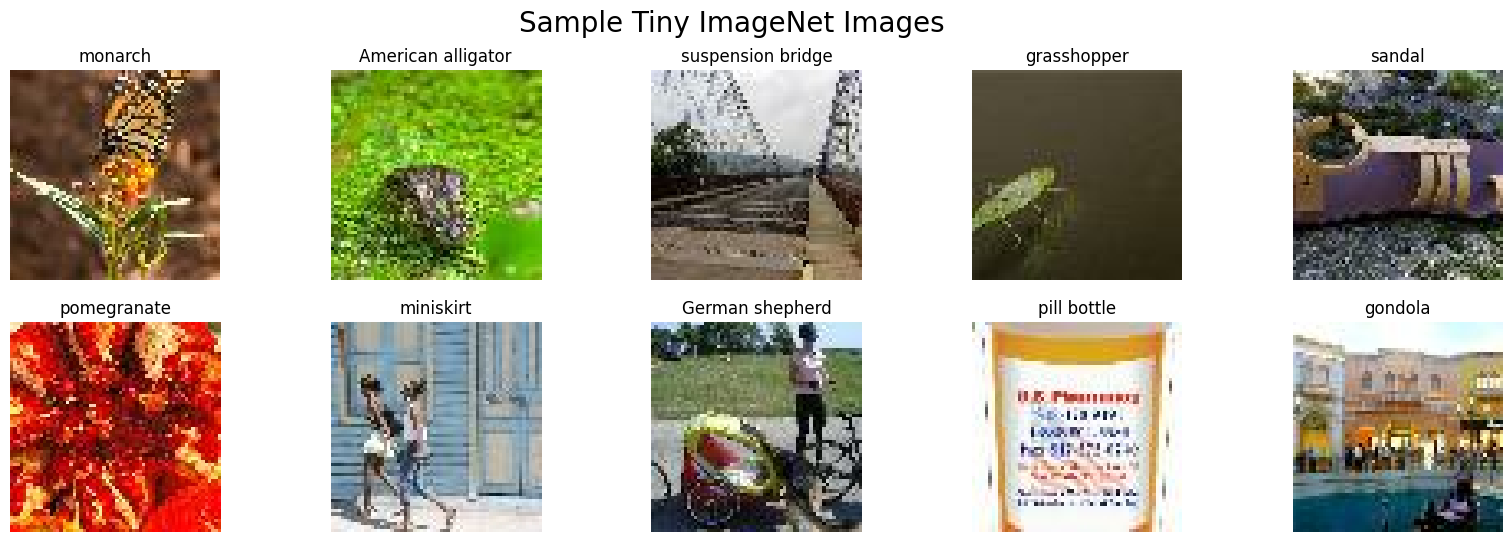

In [155]:
from tiny_imagenet import TinyImagenetDataset

tiny_imagenet_builder = TinyImagenetDataset()
tiny_imagenet_builder.download_and_prepare()

# Load Tiny ImageNet dataset
(train_ds, val_ds), info = tiny_imagenet_builder.as_dataset(
    split=["train", "validation"],
    # as_supervised=True,
), tiny_imagenet_builder.info

print(f"Training dataset has {info.splits['train'].num_examples} examples")
print(f"Validation dataset has {info.splits['validation'].num_examples} examples")

# Display some sample images
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
for i, data in enumerate([
    list(train_ds.take(5)), list(val_ds.take(5)),
]):
    for j in range(5):
        label = data[j]["metadata"]["label_name"].numpy().decode('utf-8')
        axes[i][j].imshow(data[j]["image"], cmap='gray')
        axes[i][j].set_title(label.split(",")[0])
        axes[i][j].axis('off')

plt.suptitle("Sample Tiny ImageNet Images", fontsize=20)
plt.show()

In [156]:
from functools import partial

def get_transform(data, img_size=224):
    image = tf.image.resize(data["image"], (img_size, img_size))
    image = tf.cast(image, tf.float32) / 255.0
    label = data["label"]
    return image, label

IMG_SIZE = 32
BATCH_SIZE = 512
DATA_LEN = info.splits["train"].num_examples

# Preprocess data
train_ds_proc = (
    train_ds
    .map(partial(get_transform,img_size=IMG_SIZE),
         num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .shuffle(DATA_LEN, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds_proc = (
    val_ds
    .map(partial(get_transform,img_size=IMG_SIZE),
         num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

for data in [train_ds_proc, val_ds_proc]:
    spec = data.element_spec
    print(f"Images of training dataset have shape: {spec[0].shape}, dtype: {spec[0].dtype.name}")
    print(f"Labels of training dataset have shape: {spec[1].shape}, dtype: {spec[1].dtype.name}")

# None in the first index means batch size

Images of training dataset have shape: (None, 32, 32, 3), dtype: float32
Labels of training dataset have shape: (None,), dtype: int64
Images of training dataset have shape: (None, 32, 32, 3), dtype: float32
Labels of training dataset have shape: (None,), dtype: int64


In [ ]:
# Create model
model = Sequential([
    layers.Input(shape=train_ds_proc.element_spec[0].shape[1:], name="input_layer"),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name="conv1"),
    layers.MaxPooling2D((2, 2), name="pool1"),
    layers.Dropout(0.3, name="drop1"),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name="conv2"),
    layers.MaxPooling2D((2, 2), name="pool2"),
    layers.Dropout(0.3, name="drop2"),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same', name="conv3"),
    layers.MaxPooling2D((2, 2), name="pool3"),
    layers.Dropout(0.3, name="drop3"),

    layers.GlobalAveragePooling2D(name="gap"),
    
    # Head
    layers.Dense(128, activation='relu', name="fc1"), 
    # layers.Dropout(0.3, name="drop_fc"),   
    layers.Dense(200, activation='softmax', name="output_layer")
], name="cnn_object_classifier_timagenet")

initial_weights = model.get_weights()
model.summary()

Model: "cnn_object_classifier_timagenet"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1 (Conv2D)              (None, 32, 32, 32)        896       
                                                                 
 pool1 (MaxPooling2D)        (None, 16, 16, 32)        0         
                                                                 
 drop1 (Dropout)             (None, 16, 16, 32)        0         
                                                                 
 conv2 (Conv2D)              (None, 16, 16, 64)        18496     
                                                                 
 pool2 (MaxPooling2D)        (None, 8, 8, 64)          0         
                                                                 
 drop2 (Dropout)             (None, 8, 8, 64)          0         
                                                                 
 conv3 (Conv2D)              (None,

In [ ]:
# Reset weights
model.set_weights(initial_weights)

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-3, 
        weight_decay=1e-4
    ), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
mcp_save = ModelCheckpoint(f'{CKPT_PATH}/cnn_object_recognizer_timagenet.keras', save_best_only=True, verbose=1, monitor='val_loss')

# Train model with history tracking
result = model.fit(
    train_ds_proc,
    epochs=150, 
    validation_data=val_ds_proc, 
    callbacks=[early_stopping, mcp_save],
)

Epoch 1/150


2026-02-15 18:06:29.936273: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:1014] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape incnn_object_classifier_timagenet/drop1/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


193/196 [============================>.] - ETA: 0s - loss: 5.1516 - accuracy: 0.0129
Epoch 1: val_loss improved from inf to 4.94006, saving model to /app/checkpoints/cnn_object_recognizer_timagenet3.keras
196/196 [==============================] - 6s 19ms/step - loss: 5.1496 - accuracy: 0.0130 - val_loss: 4.9401 - val_accuracy: 0.0285
Epoch 2/150
193/196 [============================>.] - ETA: 0s - loss: 4.8595 - accuracy: 0.0346
Epoch 2: val_loss improved from 4.94006 to 4.71191, saving model to /app/checkpoints/cnn_object_recognizer_timagenet3.keras
196/196 [==============================] - 4s 19ms/step - loss: 4.8588 - accuracy: 0.0347 - val_loss: 4.7119 - val_accuracy: 0.0486
Epoch 3/150
193/196 [============================>.] - ETA: 0s - loss: 4.6793 - accuracy: 0.0502
Epoch 3: val_loss improved from 4.71191 to 4.58326, saving model to /app/checkpoints/cnn_object_recognizer_timagenet3.keras
196/196 [==============================] - 4s 19ms/step - loss: 4.6788 - accuracy: 0.0503

20/20 [==============================] - 0s 7ms/step - loss: 3.0476 - accuracy: 0.3015
Test Accuracy: 30.15%


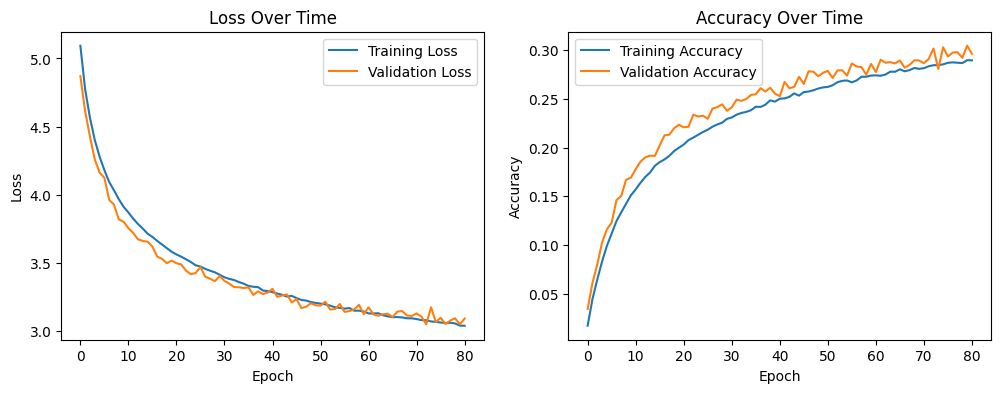

In [ ]:
# Evaluate model
model.load_weights(f'{CKPT_PATH}/cnn_object_recognizer_timagenet.keras')
loss, accuracy = model.evaluate(val_ds_proc)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training history
generate_plot(result)

1/1 [==============================] - 0s 52ms/step


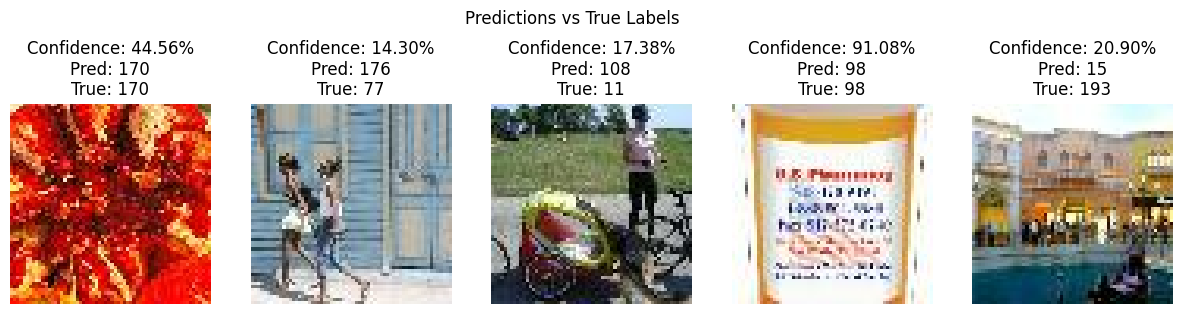

In [ ]:
X_sample, y_sample = next(iter(val_ds_proc.take(1)))

# Predict on test set and visualize some results
model.load_weights(f'{CKPT_PATH}/cnn_object_recognizer_timagenet.keras')
scores = model.predict(X_sample[:5])
predictions = np.argmax(scores, axis=1) # Get predicted class from the max confidence score
y_true = y_sample[:5]

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i in range(5):
    axes[i].imshow(X_sample[i], cmap='gray')
    axes[i].set_title(f"Confidence: {scores[i][predictions[i]]*100:.2f}%\nPred: {predictions[i]}\nTrue: {y_true[i]}")
    axes[i].axis('off')
plt.suptitle("Predictions vs True Labels")
plt.show()